In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [5]:
start_idx = 40 + 12  # 52
end_idx = start_idx + 128  # 180

X_mel = data.iloc[:, start_idx:end_idx].values
X_mel.shape

(1440, 128)

In [6]:
import numpy as np

X_log_mel = np.log(X_mel + 1e-9)
X_log_mel.shape

(1440, 128)

In [7]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
y = data.iloc[:, -2].values
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)
y1 = to_categorical(y_encoded)

In [8]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(1440, 8))

In [10]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [11]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [12]:
X3=pd.DataFrame(X_log_mel)
X3

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-13.684820,-10.422137,-6.560049,-4.124156,-3.408663,-3.300337,-4.609446,-5.272507,-3.633397,-3.550744,...,-11.566824,-11.837624,-12.140788,-12.212571,-12.267146,-12.131390,-12.092491,-11.683669,-12.115280,-12.556879
1,-13.403423,-10.168345,-6.380846,-4.361033,-3.207077,-2.729368,-4.246620,-5.594941,-4.141622,-3.316785,...,-10.903223,-11.707669,-12.077964,-11.971253,-12.391627,-12.172353,-11.697730,-11.713855,-12.146747,-12.285828
2,-12.814213,-10.096292,-6.818060,-4.077254,-3.121942,-2.970935,-4.997382,-5.044250,-3.512324,-3.456030,...,-9.433482,-9.916138,-10.497355,-10.224201,-10.366882,-10.492403,-10.788893,-10.759134,-11.087351,-11.501132
3,-13.128662,-10.405863,-5.989493,-3.779445,-2.808630,-2.826763,-5.524860,-5.344933,-3.920086,-3.528420,...,-9.672686,-10.561098,-10.910240,-11.065599,-10.520426,-10.170772,-10.165548,-10.687069,-10.544375,-10.484288
4,-13.071989,-10.364260,-7.777426,-4.897601,-3.844014,-3.428338,-4.009785,-5.913872,-4.435675,-3.813214,...,-10.961358,-11.762163,-11.727020,-11.995994,-11.842671,-11.929158,-11.806645,-12.062348,-11.785205,-11.793509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-13.578549,-11.299945,-9.778122,-9.391509,-10.716374,-11.181252,-10.409003,-6.796625,-4.061356,-3.385541,...,-6.353002,-6.173533,-6.356092,-6.913447,-7.088687,-7.366046,-7.475786,-7.363767,-7.503339,-7.763666
1436,-9.611212,-9.181080,-8.383670,-8.185095,-8.881710,-9.135415,-8.472817,-5.196415,-2.859766,-2.577447,...,-7.801436,-8.053623,-7.640512,-7.224197,-6.935966,-7.025061,-7.059534,-6.960290,-6.942616,-6.893430
1437,-9.826602,-10.666152,-8.505561,-7.271593,-8.299093,-8.509542,-8.931463,-6.025257,-3.171233,-2.212802,...,-8.089841,-7.993902,-7.587240,-7.228851,-7.473797,-7.458182,-7.788957,-7.566123,-7.506234,-7.687065
1438,-5.501596,-6.503769,-7.531548,-8.001074,-8.456941,-8.242271,-7.929342,-6.361278,-4.663691,-3.204490,...,-3.965731,-4.308568,-4.238467,-4.314104,-4.301558,-4.438795,-4.219530,-4.203744,-4.166988,-4.406814


In [15]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=535
num_fea=125
a=create_index(kfold,totalsize)
savedir='ravdess_log_mel'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y[train_idx], y[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 1152 | Test: 288
Top 125 features: [120 118 123 126 127 125 124 122 121 119] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2786 - loss: 1.9417 - val_accuracy: 0.1319 - val_loss: 2.0831
Epoch 2/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3611 - loss: 1.7217 - val_accuracy: 0.1319 - val_loss: 2.1387
Epoch 3/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3689 - loss: 1.6372 - val_accuracy: 0.1319 - val_loss: 2.2171
Epoch 4/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4340 - loss: 1.5420 - val_accuracy: 0.1319 - val_loss: 2.2839
Epoch 5/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4410 - loss: 1.4842 - val_accuracy: 0.1319 - val_loss: 2.3170
Epoch 6/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5043 - loss: 1.4218 - val_accuracy: 0.1319 - val_loss: 2.3303
Epoch 7/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5000 - loss: 1.4018 - val_accuracy: 0.1319 - val_loss: 2.3338
Epoch 8/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5356 - loss: 1.3336 - val_accuracy: 0.1319 - val_l

Fold 0 Test Accuracy: 0.5694

===== Fold 1 =====
Train: 1152 | Test: 288
Top 125 features: [120 118 124 126 127 125 123 122 121 119] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2743 - loss: 1.8948 - val_accuracy: 0.1319 - val_loss: 2.1013
Epoch 2/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3628 - loss: 1.6898 - val_accuracy: 0.1354 - val_loss: 2.1540
Epoch 3/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3932 - loss: 1.6064 - val_accuracy: 0.1354 - val_loss: 2.2257
Epoch 4/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4653 - loss: 1.5042 - val_accuracy: 0.1354 - val_loss: 2.2776
Epoch 5/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4861 - loss: 1.4527 - val_accuracy: 0.1354 - val_loss: 2.3017
Epoch 6/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5130 - loss: 1.3832 - val_accuracy: 0.1354 - val_loss: 2.3274
Epoch 7/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5434 - loss: 1.3448 - val_accuracy: 0.1354 - val_loss: 2.3479
Epoch 8/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5755 - loss: 1.3132 - val_accuracy: 0.1354 - val_l

Fold 3 Test Accuracy: 0.5938

===== Fold 4 =====
Train: 1152 | Test: 288
Top 125 features: [120 118 124 126 127 125 123 122 121 119] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2474 - loss: 1.9606 - val_accuracy: 0.1562 - val_loss: 2.1066
Epoch 2/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3472 - loss: 1.7004 - val_accuracy: 0.1632 - val_loss: 2.1855
Epoch 3/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3854 - loss: 1.6385 - val_accuracy: 0.1736 - val_loss: 2.2794
Epoch 4/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4358 - loss: 1.5355 - val_accuracy: 0.1562 - val_loss: 2.3429
Epoch 5/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4592 - loss: 1.4848 - val_accuracy: 0.1493 - val_loss: 2.3797
Epoch 6/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4792 - loss: 1.4505 - val_accuracy: 0.1493 - val_loss: 2.3819
Epoch 7/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5226 - loss: 1.3744 - val_accuracy: 0.1493 - val_loss: 2.3955
Epoch 8/700
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5668 - loss: 1.3076 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.6146

===== Cross-validation results =====
Fold 0: Loss=1.2464, Accuracy=0.5694
Fold 1: Loss=1.1763, Accuracy=0.5799
Fold 2: Loss=1.1565, Accuracy=0.6007
Fold 3: Loss=1.1890, Accuracy=0.5938
Fold 4: Loss=1.1839, Accuracy=0.6146

Average accuracy: 0.5917


In [17]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'ravdess_log_mel'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Fold 0: Accuracy = 56.94%
Fold 1: Accuracy = 57.99%
Fold 2: Accuracy = 60.07%
Fold 3: Accuracy = 59.38%
Fold 4: Accuracy = 61.46%

Mean Accuracy: 59.17%
SD Accuracy: 1.58
95% CI: ± 1.38


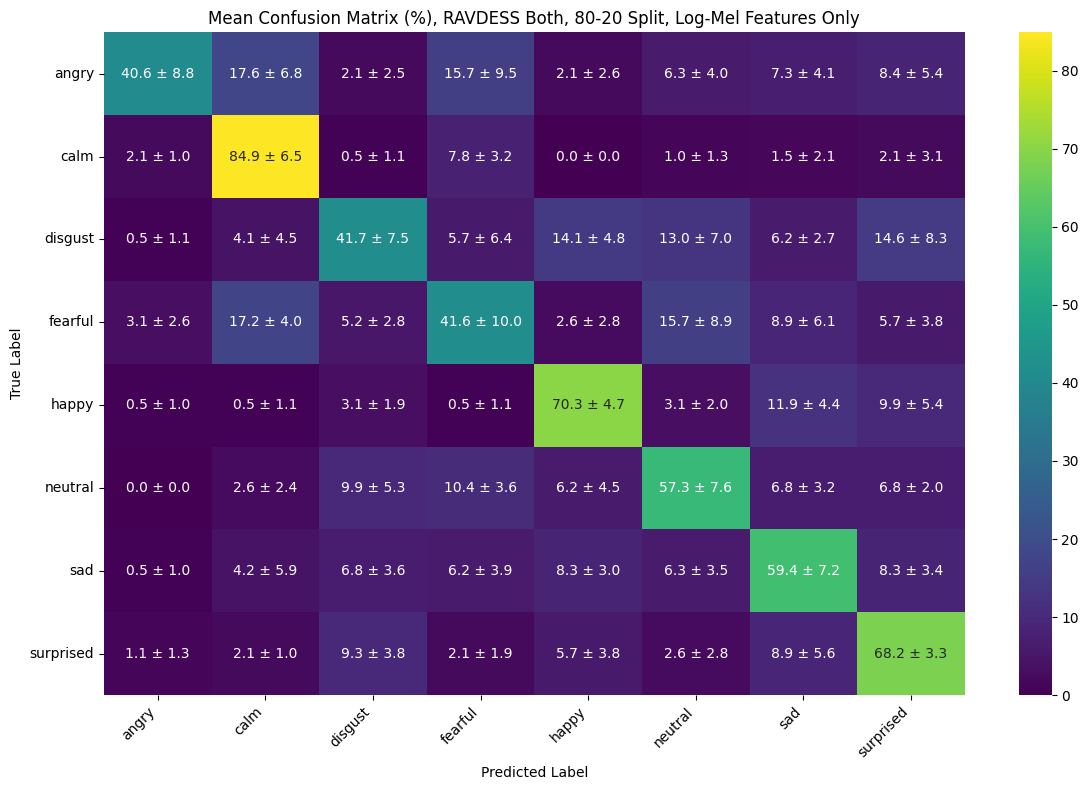

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), RAVDESS Both, 80-20 Split, Log-Mel Features Only")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
